# SG-conditioned Managed Money nowcasts

Can SG information improve the **volatility + carry** model from [`nn_carry_volatility.ipynb`](nn_carry_volatility.ipynb)? We test three ideas separately, then combine them. Notation follows that notebook.

## Target and timing

Estimate the MM position change ending Tuesday $t$:

$$
\Delta MM_{m,t}=MM_{m,t}-MM_{m,t-1}.
$$

- **Train:** preceding 104 complete weeks, excluding $t$.
- **Energy inputs:** prices through Tuesday $t$ — a **same-week nowcast**.
- **SG states:** through the previous report minus two business days.
- **SG training:** historical returns only, ending before the target week.

The SG publication buffer is an assumption: release timestamps are unavailable.

## Baseline: volatility + carry

The volatility NN estimates $\widehat{\Delta MM}^{risk}_{m,t}$ (defined below); a carry correction, fitted to its past out-of-sample errors, adds:

$$
\widehat{\Delta MM}^{base}_{m,t}=\widehat{\Delta MM}^{risk}_{m,t}+s_{m,t}\,\gamma_{m,t}\,\Delta z_{m,t}.
$$

$s_{m,t}$ is the lagged position scale (`mm_std_lag`); $z_{m,t}$ is standardized carry and $\gamma_{m,t}$ its market-specific coefficient — both as in `nn_carry_volatility.ipynb`.

## Three experiments

| Idea | Change | Control |
|---|---|---|
| **1. SG conditioning** | Scale $\widehat{\Delta MM}^{risk}_{m,t}$ by $1+a^\top\tilde s_{t-1}$, using standardized SG states | Energy-only states |
| **2. Longer horizons** | Add an SG-informed position flow from 20/60/125/250/500-day signals | Fixed weights; SG horizons ≤ 250 days |
| **3. Joint training** | Share momentum factors between the MM and SG return objectives | Volatility NN without the SG loss |

Each idea is tested **with and without carry**. The combined model adds SG conditioning, long-horizon flow, and carry to the jointly trained NN.

## What is different?

[The earlier SG notebook](sg_input_feature.ipynb) tried **additive SG flow and residual features**, including individual daily residuals. They did not improve its baseline; strong shrinkage mostly removed the correction.

Here SG changes **momentum strength, horizon weights, or training** instead of adding a feature. SG residuals are not treated as discretionary energy flow.

## Evaluation

- Identical market-weeks for every model.
- Historical validation selects correction penalties, including **no extra feature**.
- Joint-loss weight and conditioning windows stay fixed.
- Results remain exploratory: this historical period has already informed the hypotheses.

In [10]:
from pathlib import Path
import sys, json, hashlib, platform, time
from dataclasses import asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'paper_replication').is_dir())
PROJECT_ROOT = REPO_ROOT / 'paper_replication'
sys.path[:0] = [str(PROJECT_ROOT / 'src'), str(REPO_ROOT / 'working_ideas' / 'src')]
from paper_replication.config import ReplicationConfig
from paper_replication.data import load_inputs
from paper_replication.evaluate import run_replication
import sg_features as sf

# Full evaluation, as requested. These preserve the original training schedule.
config = ReplicationConfig(data_dir=PROJECT_ROOT / 'data_required', evaluation_start='2015-01-01',
                           evaluation_end='2025-12-31', train_weeks=104, seed=7)
settings = sf.ExperimentSettings(sg_lag_bdays=2, joint_weight=0.1)
SCORE_START = '2017-01-01'
OUTPUT = PROJECT_ROOT / 'outputs' / 'sg_conditioned_mm'
OUTPUT.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(1)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
started = time.monotonic()
print('Full evaluation:', config.evaluation_start, 'to', config.evaluation_end)
print('SG publication assumption:', settings.sg_lag_bdays, 'business days')

Full evaluation: 2015-01-01 to 2025-12-31
SG publication assumption: 2 business days


## 0. Refit and audit the baseline

Carry $z_{m,t}$ is the held-contract minus same-delivery-month-next-year price spread, annualized and volatility-normalized, averaged over four reports; scaling and imputation use only training history. The carry correction fits each market's previous 104 out-of-sample normalized errors, so stacking corrections later adds no extra warm-up: every experiment fits carry and its own new terms together, on the same historical errors.

The volatility NN estimates

$$
\widehat{\Delta MM}^{risk}_{m,t}=s_{m,t}\left[\hat y_{m,t}-\hat y_{m,t-1}\right],\qquad
\hat y_{m,t}=b_{m,t}+\left(\frac{\nu^{ref}_{m,t}}{\nu_{m,t}}\right)^{\alpha}T_{m,t},
$$

with $b$ the bias, $T$ the momentum trend, $\nu$ volatility, $\nu^{ref}$ its 104-week median, and $\alpha\in[0,1]$ jointly fitted — identical to `nn_carry_volatility.ipynb`. We rebuild it in a reusable library (`sg_features.py`) rather than executing that notebook.

In [11]:
reference = run_replication(config, progress=True)
prices, meta, _ = load_inputs(config)
data = sf.prepare(reference, prices, meta, config.data_dir)
original = reference['predictions'].copy()
risk = sf.run_network(data, config, settings)
risk_design = sf.carry_design(risk, data)
risk_carry = sf.with_carry(risk, data)
predictions = {'Original NN': original, 'Volatility NN': risk, 'Volatility + carry': risk_carry}
# Small checkpoints make long runs inspectable without treating old outputs as a cache.
for name, frame in predictions.items():
    frame.to_csv(OUTPUT / (name.lower().replace(' ', '_') + '.csv'), index=False)
baseline_summary, _, _, _ = sf.compare(predictions, SCORE_START, config.evaluation_end)
display(baseline_summary.round(3))
assert (risk.mm_train_end < risk.report_week_tuesday).all()

Volatility NN: 100%|██████████| 611/611 [00:19<00:00, 32.04week/s]


,R² (%),Direction (%),MAE (contracts),Observations
Original NN,45.364,72.518,10777.829,2820.0
Volatility NN,46.271,72.660,10664.048,2820.0
Volatility + carry,47.345,73.475,10582.932,2820.0


## 1. Does SG change the strength of the momentum response?

We correct the volatility prediction with a carry term and an SG-state interaction:

$$
\widehat{\Delta MM}^{gate}_{m,t}=\widehat{\Delta MM}^{risk}_{m,t}+s_{m,t}\left[\gamma_{m,t}\,\Delta z_{m,t}+\big(a^\top\tilde s_{t-1}\big)\,\hat y^{risk}_{m,t}\right],\qquad
\hat y^{risk}_{m,t}=\frac{\widehat{\Delta MM}^{risk}_{m,t}}{s_{m,t}}.
$$

$\tilde s_{t-1}$ holds two **lagged SG states** (60-day SG return volatility, 60-day correlation with an equal-weight energy trend rule's P&L) — not current SG residuals. The energy-only control replaces them with the rule's own volatility and mean/volatility ratio. No sign is imposed on $a$: the interaction can strengthen or weaken the prediction.

Features are standardized inside each historical fit. Carry gets market-specific coefficients; the SG/energy terms share pooled coefficients. For each target week: fit on the first 78 of the preceding 104 weeks, validate on the last 26, choose among penalties 1/10/100 and **no new feature** by validation SSE (matching pooled R²), then refit on all 104 weeks. This is a small linear interaction model, not another NN.

In [12]:
states = sf.conditioning_features(data, settings)
gate_design = risk_design.merge(states, on='report_week_tuesday', how='left', validate='many_to_one')
sg_states = ['sg_vol', 'sg_alignment']
energy_states = ['energy_vol', 'energy_strength']
assert (states.state_date <= states.cutoff).all()
for label, columns in [('SG gate', sg_states), ('Energy gate control', energy_states)]:
    for carry in [False, True]:
        name = label + (' + carry' if carry else '')
        predictions[name] = sf.rolling_overlay(gate_design, columns, settings, carry=carry, interaction=True)
summary1, _, _, _ = sf.compare(predictions, SCORE_START, config.evaluation_end)
display(summary1.round(3))

,R² (%),Direction (%),MAE (contracts),Observations
Original NN,45.364,72.518,10777.829,2820.0
Volatility NN,46.271,72.660,10664.048,2820.0
Volatility + carry,47.345,73.475,10582.932,2820.0
SG gate,46.343,72.660,10657.892,2820.0
SG gate + carry,47.423,73.511,10575.437,2820.0
Energy gate control,46.332,72.660,10657.570,2820.0
Energy gate control + carry,47.402,73.511,10575.567,2820.0


## 2. Can SG identify useful slower horizons?

Use a constrained library of normalized momentum/reaction strategies at **20, 60, 125, 250, 500 days**. For each test year, fit nonnegative ridge weights $w_h\geq0$ to historical daily SG returns using energy strategy P&L, training on the prior four years and selecting the penalty on the last training year. All dates respect the SG availability buffer — this is daily return replication, not a next-day SG forecast.

The resulting MM feature is a weekly position flow, both endpoints from the same annual weights:

$$
f^{SG}_{m,t}=\frac{h_{m,t}}{\nu_{m,t}}-\frac{h_{m,t-1}}{\nu_{m,t-1}},\qquad h_{m,t}=\sum_h w_h\,\text{position}_{h,m,t}.
$$

Its units are arbitrary; the historical carry-style correction maps it into MM contracts.

Controls separate three explanations:
- **Fixed long blend:** equal horizon weights, no SG data.
- **SG short blend:** SG fit with horizons only through 250 days.
- **SG long blend:** SG fit including 500 days.

Each is tested against the volatility base, with and without carry. The fixed blend is a no-SG control, not a separately trained long-horizon MM network.

In [13]:
long_flows, long_weights = sf.horizon_flows(data, settings)
short_flows, short_weights = sf.horizon_flows(data, settings, horizons=(20, 60, 125, 250))
flows = long_flows.rename(columns={'sg_flow': 'sg_long_flow', 'fixed_flow': 'fixed_long_flow'}).merge(
    short_flows[sf.KEYS + ['sg_flow']].rename(columns={'sg_flow': 'sg_short_flow'}),
    on=sf.KEYS, validate='one_to_one')
horizon_design = risk_design.merge(flows, on=sf.KEYS, how='left', validate='one_to_one')
for label, column in [('Fixed long control', 'fixed_long_flow'), ('SG short horizons', 'sg_short_flow'),
                      ('SG long horizons', 'sg_long_flow')]:
    for carry in [False, True]:
        predictions[label + (' + carry' if carry else '')] = sf.rolling_overlay(
            horizon_design, [column], settings, carry=carry)
display(long_weights.round(4))
summary2, _, _, _ = sf.compare(predictions, SCORE_START, config.evaluation_end)
display(summary2.round(3))

,year,train_end,penalty,weight_20,weight_60,weight_125,weight_250,weight_500
0,2014,2013-12-27,1.0,0.0010,0.0054,0.0223,0.0294,0.0179
1,2015,2014-12-29,1.0,0.0024,0.0057,0.0149,0.0257,0.0188
2,2016,2015-12-29,0.1,0.0036,0.0065,0.0318,0.0479,0.0097
3,2017,2016-12-28,10.0,0.0021,0.0038,0.0045,0.0054,0.0041
4,2018,2017-12-27,1.0,0.0062,0.0135,0.0158,0.0219,0.0132
5,2019,2018-12-27,0.1,0.0055,0.0176,0.0340,0.0401,0.0181
6,2020,2019-12-27,1.0,0.0009,0.0128,0.0196,0.0221,0.0139
7,2021,2020-12-29,0.1,0.0000,0.0105,0.0475,0.0293,0.0000
8,2022,2021-12-29,0.1,0.0000,0.0076,0.0518,0.0350,0.0070
9,2023,2022-12-28,0.1,0.0041,0.0083,0.0572,0.0226,0.0032


,R² (%),Direction (%),MAE (contracts),Observations
Original NN,45.364,72.518,10777.829,2820.0
Volatility NN,46.271,72.660,10664.048,2820.0
Volatility + carry,47.345,73.475,10582.932,2820.0
SG gate,46.343,72.660,10657.892,2820.0
SG gate + carry,47.423,73.511,10575.437,2820.0
Energy gate control,46.332,72.660,10657.570,2820.0
Energy gate control + carry,47.402,73.511,10575.567,2820.0
Fixed long control,46.504,72.553,10640.813,2820.0
Fixed long control + carry,47.576,73.404,10557.765,2820.0
SG short horizons,46.450,72.660,10645.482,2820.0


## 3. Jointly train MM positions and SG returns

The network keeps the original 50 momentum horizons and three factors. The MM head keeps market-specific factor weights and a time-varying bias, as in $\widehat{\Delta MM}^{risk}$ above. A separate SG head shares the same momentum factors and volatility exponent $\alpha$, with its own intercept:

$$
L=L_{MM}+0.1\,L_{SG}+\text{parameter penalties},\qquad
L_{SG}=\operatorname{MSE}\!\left(\widehat r^{SG}_d,\ r^{SG}_d/\kappa_{train}\right).
$$

$\widehat r^{SG}_d$ sums prior-close risk-scaled energy positions × realized daily energy risk returns; $\kappa_{train}$ is the SG return's training-window standard deviation. SG uses the preceding 504 available trading days, ending before the target week; MM still uses the 104 preceding complete weeks. Both losses use their sample means, so daily observations do not automatically overwhelm weekly ones.

The joint weight **0.1 is fixed in advance**, not selected from the reported test period; setting it to zero recovers the volatility architecture exactly. We compare both the raw joint NN and a carry correction fitted to its own historical out-of-sample errors. Negative transfer is possible: an energy-only model cannot explain SG's entire diversified portfolio.

In [14]:
joint = sf.run_network(data, config, settings, joint_weight=settings.joint_weight)
joint_carry = sf.with_carry(joint, data)
predictions['Joint MM/SG NN'] = joint
predictions['Joint MM/SG + carry'] = joint_carry
assert (joint.sg_train_end < joint.report_week_tuesday).all()
joint.to_csv(OUTPUT / 'joint_raw.csv', index=False)
summary3, _, _, _ = sf.compare(predictions, SCORE_START, config.evaluation_end)
display(summary3.round(3))

Joint MM/SG: 100%|██████████| 611/611 [00:34<00:00, 17.46week/s]


,R² (%),Direction (%),MAE (contracts),Observations
Original NN,45.364,72.518,10777.829,2820.0
Volatility NN,46.271,72.660,10664.048,2820.0
Volatility + carry,47.345,73.475,10582.932,2820.0
SG gate,46.343,72.660,10657.892,2820.0
SG gate + carry,47.423,73.511,10575.437,2820.0
Energy gate control,46.332,72.660,10657.570,2820.0
Energy gate control + carry,47.402,73.511,10575.567,2820.0
Fixed long control,46.504,72.553,10640.813,2820.0
Fixed long control + carry,47.576,73.404,10557.765,2820.0
SG short horizons,46.450,72.660,10645.482,2820.0


## 4. Combine all three ideas

Use the joint NN as the base. A single historical correction includes:
1. Market-specific carry changes.
2. Lagged SG state × normalized joint-NN prediction interactions.
3. The SG-informed long-horizon flow.

The no-extra-feature option shrinks the overlay back to joint NN + carry; it cannot undo the joint training itself. **Joint + fixed long flow + energy states** is a matched overlay control, and **risk NN + SG states + SG long flow** tests whether joint training helps the combination. We do not select a winning architecture using the final results.

In [15]:
def combination_design(base):
    return (sf.carry_design(base, data)
            .merge(states, on='report_week_tuesday', how='left', validate='many_to_one')
            .merge(flows, on=sf.KEYS, how='left', validate='one_to_one'))

combined_design = combination_design(joint)
predictions['Combined: joint + SG gate + SG long + carry'] = sf.rolling_overlay(
    combined_design, sg_states + ['sg_long_flow'], settings, carry=True, interaction=sg_states)
predictions['Joint + energy gate + fixed long + carry'] = sf.rolling_overlay(
    combined_design, energy_states + ['fixed_long_flow'], settings, carry=True, interaction=energy_states)
predictions['Risk + SG gate + SG long + carry'] = sf.rolling_overlay(
    combination_design(risk), sg_states + ['sg_long_flow'], settings, carry=True, interaction=sg_states)

## 5. Compare on identical observations

R² here is **uncentred**, `1 − sum((actual − prediction)²) / sum(actual²)`: the benchmark is predicting zero position change. Direction compares signs; MAE is in contracts. Pooled R² puts more weight on markets with larger contract changes. All tables and charts below use the intersection of valid market-weeks across **every** model, including controls.

A pooled gain alone is insufficient: inspect annual and market-level stability and whether feature selection mostly chooses “off.” The 2017–2025 period is not an untouched holdout. No statistical-significance or live-trading claim is inferred from a small R² improvement.

Common sample: 2,820 market-weeks; 2017-01-03 to 2025-12-30


,R² (%),Direction (%),MAE (contracts),Observations,ΔR² vs volatility + carry (pp)
Original NN,45.364,72.518,10777.829,2820.0,-1.981
Volatility NN,46.271,72.660,10664.048,2820.0,-1.074
Volatility + carry,47.345,73.475,10582.932,2820.0,0.000
SG gate,46.343,72.660,10657.892,2820.0,-1.002
SG gate + carry,47.423,73.511,10575.437,2820.0,0.079
Energy gate control,46.332,72.660,10657.570,2820.0,-1.012
Energy gate control + carry,47.402,73.511,10575.567,2820.0,0.058
Fixed long control,46.504,72.553,10640.813,2820.0,-0.841
Fixed long control + carry,47.576,73.404,10557.765,2820.0,0.231
SG short horizons,46.450,72.660,10645.482,2820.0,-0.895


model,Original NN,Volatility + carry,SG gate + carry,SG long horizons + carry,Joint MM/SG + carry,Combined: joint + SG gate + SG long + carry
year,,,,,,
2017,46.16,51.30,51.30,51.30,53.32,53.31
2018,45.02,45.87,45.97,45.97,47.52,47.53
2019,47.72,50.38,50.32,50.60,49.71,49.64
2020,27.03,30.28,30.40,30.67,30.11,30.48
2021,35.84,41.14,41.16,41.33,35.30,35.74
2022,37.94,32.70,32.68,32.57,30.21,29.99
2023,47.21,50.33,50.58,51.95,48.11,49.79
2024,57.09,58.34,58.33,58.48,58.09,58.09
2025,49.75,48.92,49.16,48.77,49.39,49.35


model,Original NN,Volatility + carry,SG gate + carry,SG long horizons + carry,Joint MM/SG + carry,Combined: joint + SG gate + SG long + carry
market,,,,,,
BRENT,49.67,51.74,51.80,51.68,51.53,51.51
GASOIL,48.20,51.22,51.30,51.20,51.07,51.13
HEATOIL,37.18,36.95,37.08,36.93,38.48,38.46
NATGAS,45.72,48.36,48.34,49.55,47.92,48.75
RBOB,30.06,30.30,30.60,30.23,30.80,30.78
WTI,40.54,41.86,42.02,41.87,41.59,41.70


,Fraction of scored rows with extra feature active
SG gate,0.632
SG gate + carry,0.657
Energy gate control,0.668
Energy gate control + carry,0.662
Fixed long control,0.511
Fixed long control + carry,0.536
SG short horizons,0.534
SG short horizons + carry,0.532
SG long horizons,0.504
SG long horizons + carry,0.481


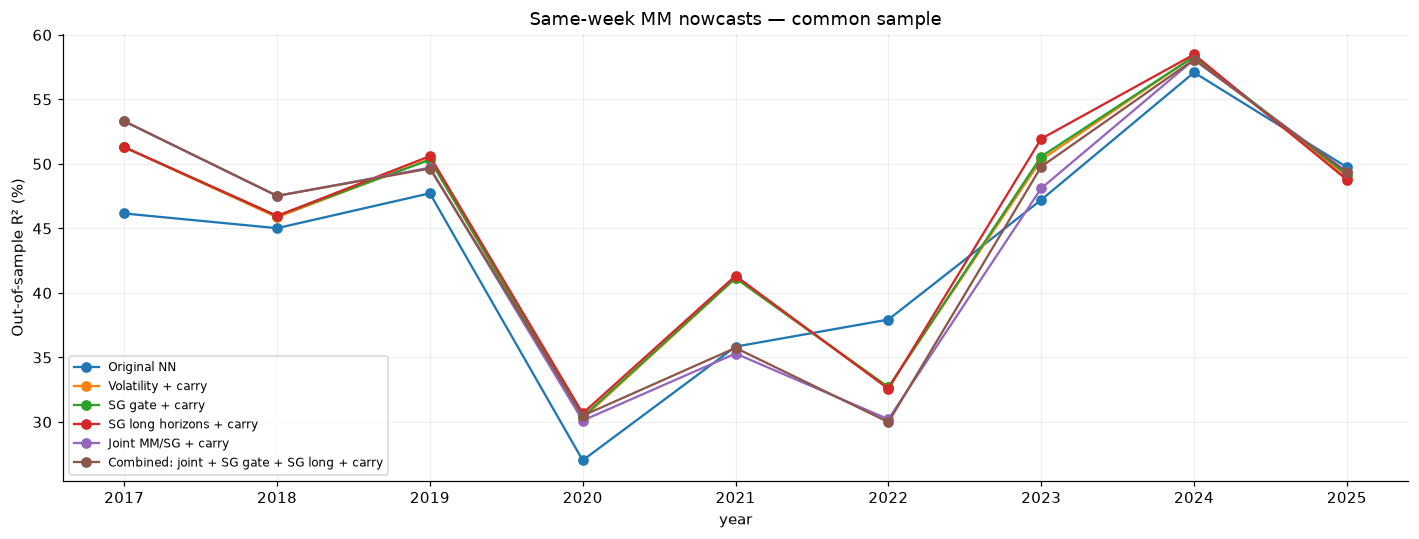

In [16]:
summary, annual, markets, aligned = sf.compare(predictions, SCORE_START, config.evaluation_end)
summary['ΔR² vs volatility + carry (pp)'] = summary['R² (%)'] - summary.loc['Volatility + carry', 'R² (%)']
sample = next(iter(aligned.values()))
print(f"Common sample: {len(sample):,} market-weeks; {sample.panel_date.min():%Y-%m-%d} to {sample.panel_date.max():%Y-%m-%d}")
display(summary.round(3))
main_models = ['Original NN', 'Volatility + carry', 'SG gate + carry', 'SG long horizons + carry',
               'Joint MM/SG + carry', 'Combined: joint + SG gate + SG long + carry']
annual_table = annual.pivot(index='year', columns='model', values='R² (%)')[main_models]
market_table = markets.pivot(index='market', columns='model', values='R² (%)')[main_models]
display(annual_table.round(2))
display(market_table.round(2))
activation = pd.Series({name: frame.new_feature_active.mean()
                       for name, frame in aligned.items() if 'new_feature_active' in frame},
                       name='Fraction of scored rows with extra feature active')
display(activation.to_frame().round(3))
ax = annual_table.plot(figsize=(13, 5), marker='o', ylabel='Out-of-sample R² (%)', title='Same-week MM nowcasts — common sample')
ax.grid(alpha=.2)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT / 'annual_r2.png', dpi=160)
plt.show()

## 6. Save the evidence and decide what to take forward

Export all raw model predictions as well as the common evaluation tables, annual SG horizon weights, feature-selection rates, and a manifest of configuration and input/source hashes. This run does not silently load pre-existing prediction CSVs.

Read the outcome in this order: Does an SG model beat volatility + carry? Does it beat its no-SG control? Is the difference stable across markets and years? If no, preserve that negative result. Any later tuning should use a declared historical validation protocol and eventually fresh data.

In [17]:
for number, (name, frame) in enumerate(predictions.items()):
    frame.to_csv(OUTPUT / f'predictions_{number:02d}.csv', index=False)
summary.to_csv(OUTPUT / 'summary.csv')
annual.to_csv(OUTPUT / 'annual_scores.csv', index=False)
markets.to_csv(OUTPUT / 'market_scores.csv', index=False)
activation.to_csv(OUTPUT / 'feature_activation.csv')
long_weights.to_csv(OUTPUT / 'sg_long_weights.csv', index=False)
short_weights.to_csv(OUTPUT / 'sg_short_weights.csv', index=False)
states.to_csv(OUTPUT / 'conditioning_states.csv', index=False)
def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()
paths = list(config.data_dir.glob('*.csv')) + [REPO_ROOT / 'working_ideas/src/sg_features.py',
                                               REPO_ROOT / 'working_ideas/src/carry_extensions.py']
manifest = {'config': asdict(config), 'settings': asdict(settings), 'score_start': SCORE_START,
            'python': platform.python_version(), 'torch': torch.__version__,
            'numpy': np.__version__, 'pandas': pd.__version__,
            'elapsed_seconds': time.monotonic() - started,
            'prediction_files': {f'predictions_{i:02d}.csv': name for i, name in enumerate(predictions)},
            'sha256': {str(p.relative_to(REPO_ROOT)): sha256(p) for p in paths}}
(OUTPUT / 'manifest.json').write_text(json.dumps(manifest, indent=2, default=str))
print('Results saved to', OUTPUT)
print(f"Elapsed: {manifest['elapsed_seconds'] / 60:.1f} minutes")

Results saved to /mnt/c/Users/Julien/Desktop/Capstone Project/paper_replication/outputs/sg_conditioned_mm
Elapsed: 3.6 minutes


## Reading the completed run

The following contrasts distinguish an improvement over the base model from an improvement attributable specifically to SG. The highest full-period score is descriptive: it is not permission to select hyperparameters using those same test observations. Inspect the annual and market tables above before taking a candidate forward. The joint-loss weight stays fixed at 0.1 even if another value might improve this historical result.

In [18]:
base = summary.loc['Volatility + carry', 'R² (%)']
contrasts = [
    ('SG gate + carry', 'Energy gate control + carry'),
    ('SG long horizons + carry', 'Fixed long control + carry'),
    ('Joint MM/SG + carry', 'Volatility + carry'),
    ('Combined: joint + SG gate + SG long + carry', 'Joint + energy gate + fixed long + carry'),
]
for candidate, control in contrasts:
    score = summary.loc[candidate, 'R² (%)']
    control_score = summary.loc[control, 'R² (%)']
    print(f'{candidate}: {score:.3f}% R²; {score-base:+.3f} pp vs baseline; {score-control_score:+.3f} pp vs {control}.')
long_name = 'SG long horizons + carry'
for label, table, key in [('years', annual, 'year'), ('markets', markets, 'market')]:
    pivot = table.pivot(index=key, columns='model', values='R² (%)')
    gain = pivot[long_name] - pivot['Volatility + carry']
    print(f'SG long horizons improves {int((gain > 0).sum())}/{len(gain)} {label}; gains (pp): {gain.round(3).to_dict()}')
print('Keep these as exploratory results; the SG-specific increment is distinct from the total gain.')

SG gate + carry: 47.423% R²; +0.079 pp vs baseline; +0.021 pp vs Energy gate control + carry.
SG long horizons + carry: 47.614% R²; +0.269 pp vs baseline; +0.038 pp vs Fixed long control + carry.
Joint MM/SG + carry: 47.111% R²; -0.233 pp vs baseline; -0.233 pp vs Volatility + carry.
Combined: joint + SG gate + SG long + carry: 47.341% R²; -0.004 pp vs baseline; -0.027 pp vs Joint + energy gate + fixed long + carry.
SG long horizons improves 6/9 years; gains (pp): {2017: -0.001, 2018: 0.103, 2019: 0.227, 2020: 0.387, 2021: 0.188, 2022: -0.137, 2023: 1.623, 2024: 0.149, 2025: -0.151}
SG long horizons improves 2/6 markets; gains (pp): {'BRENT': -0.056, 'GASOIL': -0.014, 'HEATOIL': -0.022, 'NATGAS': 1.194, 'RBOB': -0.068, 'WTI': 0.009}
Keep these as exploratory results; the SG-specific increment is distinct from the total gain.


## References and scope

- Existing local notebooks: `nn_carry_volatility.ipynb`, `nn_benchmark.ipynb`, `predict_sg_index.ipynb`, `sg_input_feature.ipynb`.
- [SG Trend Index methodology](https://wholesale.banking.societegenerale.com/fileadmin/indices_feeds/SG_Trend_Index_Methodology.pdf): diversified manager index, not energy-only positioning.
- [Decoding CTA Allocations by Trend Horizon](https://rpc.cfainstitute.org/blogs/enterprising-investor/2026/decoding-cta-allocations-by-trend-horizon): motivation for a small 20/60/125/250/500-day library. Our energy-only implementation is an experiment, not a replication of that study.

Only the repo's existing energy and SG data are used. No external data are downloaded by this notebook.